Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Data Cleaning

In [2]:
df = pd.read_csv("soi_data.csv")
print(df.head())

   STATEFIPS STATE  zipcode  agi_stub      N1   mars1   MARS2   MARS4     ELF  \
0          1    AL        0         1  659530  422590   71000  154700  610780   
1          1    AL        0         2  533640  276250  101050  141040  499310   
2          1    AL        0         3  304870  134050  109980   51600  286110   
3          1    AL        0         4  193020   56350  113100   19090  181390   
4          1    AL        0         5  315700   45000  252660   12180  297930   

   CPREP  ...  N85300  A85300  N11901  A11901  N11900   A11900  N11902  \
0  24340  ...       0       0   63060   54280  543620  1559881  541480   
1  15050  ...       0       0  100320  130848  430380  1339883  427830   
2   9600  ...       0       0   88750  186002  216080   585162  212990   
3   4530  ...       0       0   67040  189833  124860   403052  121760   
4   9000  ...     140      63  138270  657283  177730   748507  169080   

    A11902  N12000  A12000  
0  1552563    2250    5031  
1  1329439

In [3]:
# 1. Handle Misssing Values

df = df.fillna(0)

In [4]:
# 2. Standardize Column Names

df.columns = df.columns.str.lower()

In [5]:
# 3. Keep Only Required Columns

df = df[['state', 'zipcode', 'agi_stub', 'n1', 'a00100']]

In [6]:
# 4. Remove Invalid Rows

df = df[df['a00100'] > 0]
df = df[df['n1'] > 0]

In [7]:
# 5. Convert Data Types

df['a00100'] = df['a00100'].astype(float)
df['n1'] = df['n1'].astype(int)

Average Income per Return

In [8]:
df['avg_income'] = df['a00100'] / df['n1']

Exploratory Data Analysis (EDA)

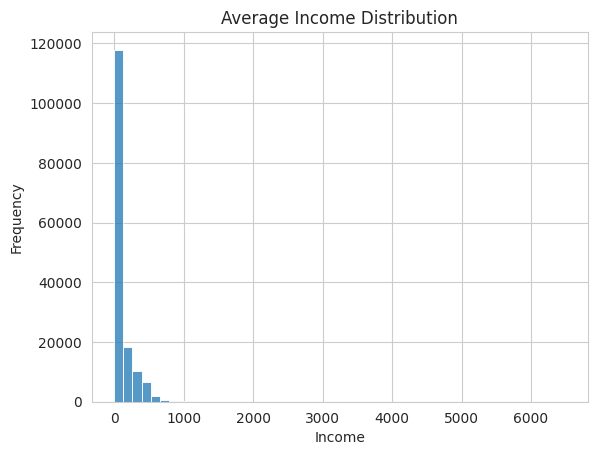

In [9]:
# 1. Income Distribution

sns.histplot(df['avg_income'], bins=50)
plt.title("Average Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

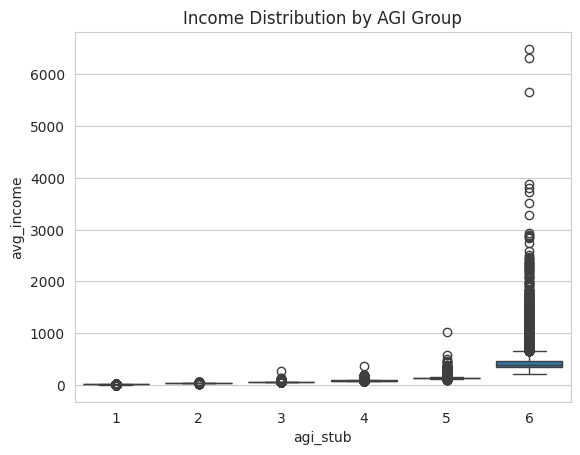

In [10]:
# 2. Income by AGI Group

sns.boxplot(x='agi_stub', y='avg_income', data=df)
plt.title("Income Distribution by AGI Group")
plt.show()

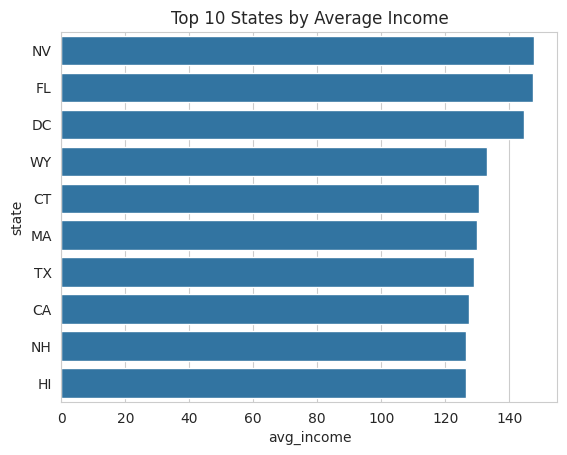

In [11]:
# 3. State-wise Income

state_income = df.groupby('state')['avg_income'].mean().reset_index()

state_income = state_income.sort_values(by='avg_income', ascending=False)

sns.barplot(x='avg_income', y='state', data=state_income.head(10))
plt.title("Top 10 States by Average Income")
plt.show()

Inequality Measurement

In [12]:
# 1. Gini Coefficient

income = df['avg_income'].values

def gini(x):
    x = np.sort(x)
    n = len(x)
    return (2 * np.sum((np.arange(1, n+1) * x)) / (n * np.sum(x))) - (n + 1) / n

gini_value = gini(income)
print("Gini Coefficient:", gini_value)

Gini Coefficient: 0.5381943337869921


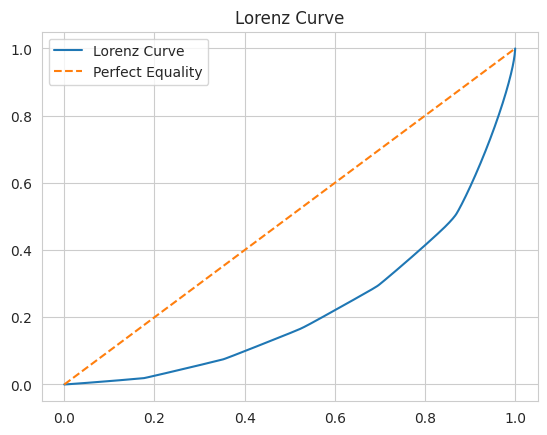

In [13]:
# 2. Lorenz Curve

def lorenz_curve(x):
    x = np.sort(x)
    cum_income = np.cumsum(x)
    cum_income = cum_income / cum_income[-1]
    cum_pop = np.arange(1, len(x)+1) / len(x)
    return cum_pop, cum_income

pop, income = lorenz_curve(df['avg_income'])

plt.plot(pop, income, label="Lorenz Curve")
plt.plot([0,1], [0,1], linestyle='--', label="Perfect Equality")
plt.legend()
plt.title("Lorenz Curve")
plt.show()

Statistical Modeling

In [14]:
# Log Transformation (Realistic for income)

df['log_income'] = np.log(df['avg_income'])

In [15]:
# Distribution Fit

from scipy.stats import norm

mu, std = norm.fit(df['log_income'])

print("Mean:", mu)
print("Std Dev:", std)

Mean: 4.1953103182355145
Std Dev: 1.0610633473201576
